# 🏆 2) Model Training

In this section you will use your gained information about our dataset to create a model that predicts the amount of demage for a car accident. 

**Tasks**: 
1) Discuss with your team which features you want to use within your model.
2) Create several models with different features. 


<img src="https://github.com/unkrejativ/axa-egoi-hands-on-session-2025/blob/setup-devspaces/modelling_sis.png" width="40"/> **Bonus**:
Extend your models by interactions or non linear relations.
- A*B indicates that there is a interaction between A and B
- np.log(A), np.exp(A), A**2 indicated a non linear realtion

**Ratings**:
The team with the best metrics will receive **2** points

<img src="https://github.com/unkrejativ/axa-egoi-hands-on-session-2025/blob/setup-devspaces/modelling_sis.png" width="40"/> **Hint**: Have a closer lookup to https://www.statsmodels.org/dev/example_formulas.html


In [9]:
# Import required packages
import pandas as pd 
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
import plotly.express as px
import seaborn as sns
from utils import plot_scatter_and_residuals, add_model_to_overview
from IPython.display import display, HTML

models_overview = pd.DataFrame(columns=['Model', 'Formula', 'MSE'])

In [2]:
# Load Dataset
url = "./../data/new/sample_solution/insurance_claims_freqsev.csv"
data = pd.read_csv(url)
data.describe()


,IDpol,ClaimAmount,VehPower,VehAge,BonusMalus,Density,DrivAge
count,2.635000e+04,2.635000e+04,26350.000000,26350.000000,26350.000000,26350.000000,26350.000000
mean,2.280372e+06,2.266139e+03,6.470398,7.342732,65.273700,2017.885541,45.103454
std,1.585048e+06,2.942287e+04,2.016314,5.165652,20.158334,4168.769488,14.708993
min,1.390000e+02,1.000000e+00,4.000000,0.000000,50.000000,2.000000,18.000000
25%,1.085728e+06,6.857250e+02,5.000000,3.000000,50.000000,115.000000,34.000000
50%,2.132549e+06,1.172000e+03,6.000000,7.000000,56.000000,519.000000,45.000000
75%,3.184032e+06,1.206527e+03,7.000000,11.000000,76.000000,2252.000000,54.000000
max,6.113971e+06,4.075401e+06,15.000000,99.000000,228.000000,27000.000000,99.000000


In [3]:
data.sort_values(by="ClaimAmount", ascending=False).head(20)


,IDpol,ClaimAmount,Area,VehPower,VehAge,BonusMalus,VehBrand,VehGas,Density,Region,DriverBirthDate,DrivAge
9751,1120377,4075400.56,B,9,13,100,B2,Regular,93,R24,2006-01-25,19
15763,110846,1403057.40,C,6,13,100,B1,Regular,203,R24,2005-01-03,20
11632,2141337,1301172.60,D,4,14,100,B2,Regular,863,R82,2007-02-11,18
17987,3122016,774411.50,E,7,7,63,B11,Diesel,9307,R82,1985-04-06,40
2869,2008127,390742.27,D,4,2,50,B4,Regular,1217,R82,1967-10-05,57
3307,3025890,369131.88,A,7,1,50,B12,Diesel,38,R21,1988-11-10,36
9994,1117644,307096.42,C,7,1,90,B3,Diesel,108,R53,2004-06-17,21
5516,158309,301635.49,A,6,3,50,B1,Diesel,10,R24,1979-03-04,46
18622,3075820,287423.00,E,7,18,50,B10,Regular,4762,R93,1946-09-18,78
18290,3150210,281897.49,D,6,4,54,B3,Diesel,1064,R24,1963-11-08,61


In [3]:
data.describe() #Großschäden noch weg
print(len(data[data["ClaimAmount"]>10000]))
data = data[data["ClaimAmount"]<10000] #extra-modell dafür

477


Split your dataset in train and test data.

<img src="https://github.com/unkrejativ/axa-egoi-hands-on-session-2025/blob/setup-devspaces/images/modelling_sis.png" width="40"/>: If you want to know why we are doing this, have a look into the FAQ

In [10]:
train, test = train_test_split(data,  test_size=0.2, random_state=41)

### 1. Model

                 MODEL PERFORMANCE                 
Mean Squared Error (MSE): 1468360.05


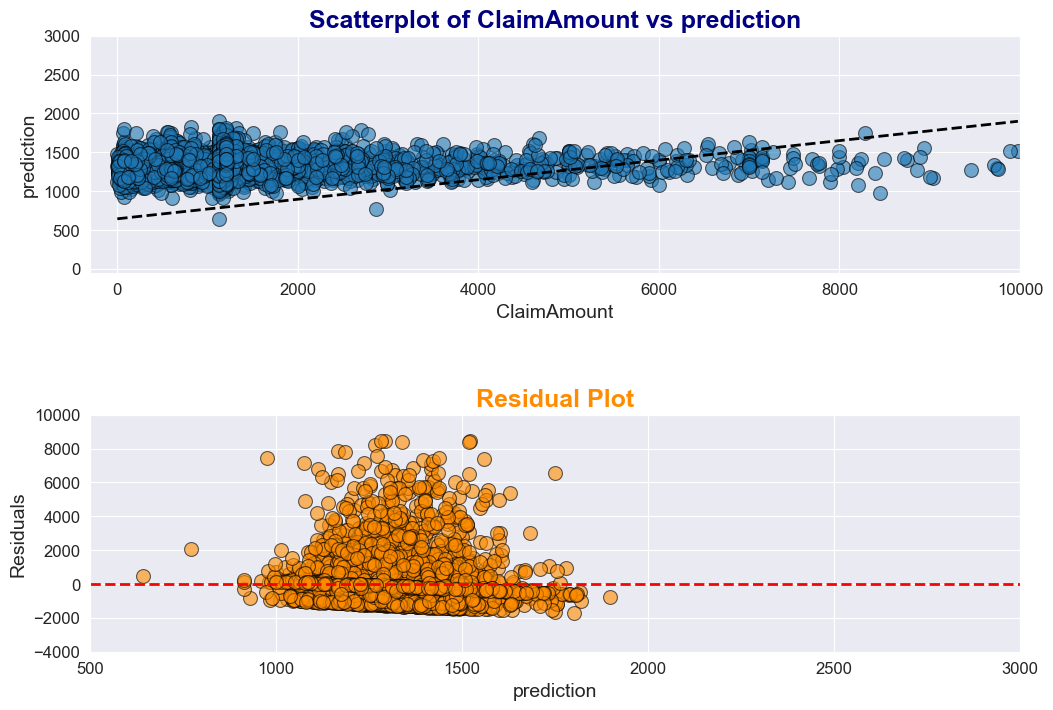

Added model_1 to the overview.
Congratulations! model_1 is your best model with the lowest MSE until now: 1468360.05.


Model,Formula,MSE
model_1,ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +C(Area) + C(VehBrand) + C(VehGas) + C(Region),1468360.05


In [11]:
formula = "ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +C(Area) + C(VehBrand) + C(VehGas) + C(Region)" 


model = smf.glm(formula, data=train, family=sm.families.Gamma(link=sm.families.links.Log())) 
results = model.fit()

#predict

test["prediction"] = results.predict(test)


#evaluate
mse = mean_squared_error(test["ClaimAmount"], test["prediction"])

print("=" * 50)  
print("                 MODEL PERFORMANCE                 ")  
print("=" * 50)  
print(f"Mean Squared Error (MSE): {mse:.2f}")  
print("=" * 50)

#visualisation
plot_scatter_and_residuals(test, "ClaimAmount", "prediction")

#add model to models_overview
models_overview = add_model_to_overview(models_overview, formula=formula, mse=mse)

display(HTML(models_overview.to_html(escape=False, index=False)))

In [7]:
formula

'ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +C(Area) + C(VehBrand) + C(VehGas) + C(Region)'

In [7]:
list(models_overview['Formula'])

['ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +C(Area) + C(VehBrand) + C(VehGas) + C(Region)',
 'ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +C(Area) + C(VehBrand) + C(VehGas) + C(Region)']

In [10]:
formula in list(models_overview['Formula'])

True

Now you trained your first model!

Look at the mse, try to find a model, that has a **lower** mse than the first model. 

Can you find the model with the lowest mse?

### 2. Model 

Now it is you turn to change the model variables!

Therefore change the variables in the "formula" variable. 
Please leave "ClaimAmount ~ " at the beginning, this determines that we want to predict the Claim Amount. 

                 MODEL PERFORMANCE                 
Mean Squared Error (MSE): 1467454.98


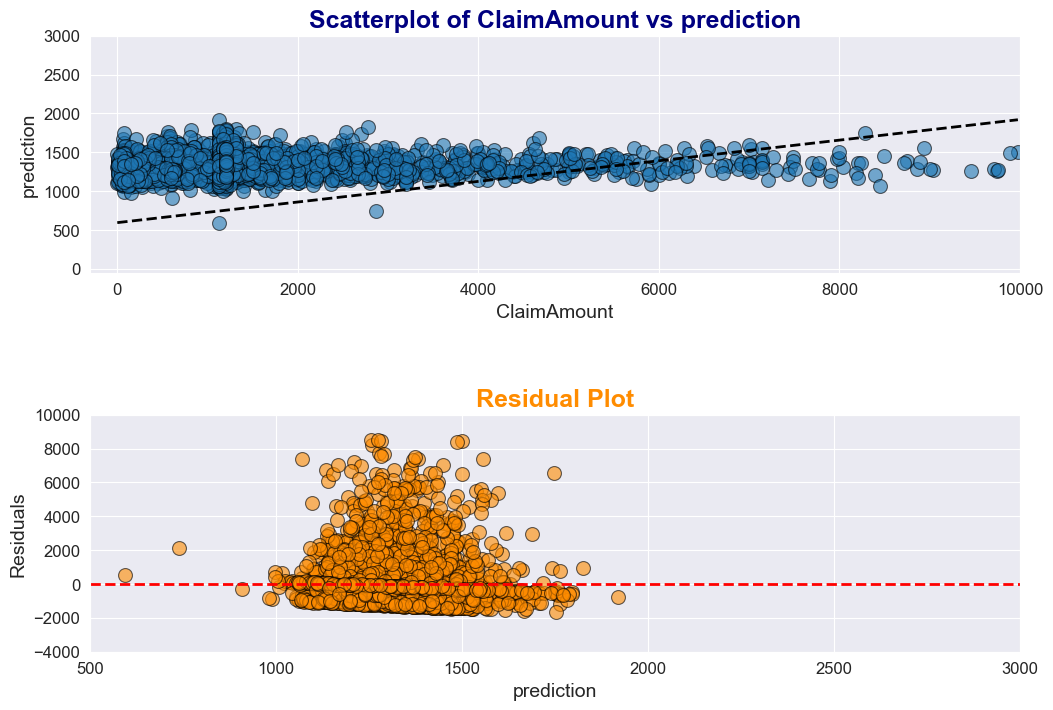

Added model_2 to the overview.
Congratulations! model_2 is your best model with the lowest MSE until now: 1467454.98.


Model,Formula,MSE
model_1,ClaimAmount ~ VehPower + VehAge + DrivAge + BonusMalus + Density +C(Area) + C(VehBrand) + C(VehGas) + C(Region),1468360.05
model_2,ClaimAmount ~ Region + DrivAge + BonusMalus + VehAge + VehPower,1467454.98


In [12]:
formula = "ClaimAmount ~ Region + DrivAge + BonusMalus + VehAge + VehPower" 


model = smf.glm(formula, data=train, family=sm.families.Gamma(link=sm.families.links.Log())) 
results = model.fit()

#predict

test["prediction"] = results.predict(test)


#evaluate
mse = mean_squared_error(test["ClaimAmount"], test["prediction"])

print("=" * 50)  
print("                 MODEL PERFORMANCE                 ")  
print("=" * 50)  
print(f"Mean Squared Error (MSE): {mse:.2f}")  
print("=" * 50)

#visualisation
plot_scatter_and_residuals(test, "ClaimAmount", "prediction")

#add model to models_overview
models_overview = add_model_to_overview(models_overview, formula=formula, mse=mse)

display(HTML(models_overview.to_html(escape=False, index=False)))

### 3.Model

In [ ]:
formula = "ClaimAmount ~ INSERT_YOUR_VARIABLES_HERE" 


model = smf.glm(formula, data=train, family=sm.families.Gamma(link=sm.families.links.Log())) 
results = model.fit()

#predict

test["prediction"] = results.predict(test)


#evaluate
mse = mean_squared_error(test["ClaimAmount"], test["prediction"])

print("=" * 50)  
print("                 MODEL PERFORMANCE                 ")  
print("=" * 50)  
print(f"Mean Squared Error (MSE): {mse:.2f}")  
print("=" * 50)

#visualisation
plot_scatter_and_residuals(test, "ClaimAmount", "prediction")

#add model to models_overview
models_overview = add_model_to_overview(models_overview, formula=formula, mse=mse)

display(HTML(models_overview.to_html(escape=False, index=False)))

### 4.Model

In [ ]:
formula = "ClaimAmount ~ INSERT_YOUR_VARIABLES_HERE" 


model = smf.glm(formula, data=train, family=sm.families.Gamma(link=sm.families.links.Log())) 
results = model.fit()

#predict

test["prediction"] = results.predict(test)


#evaluate
mse = mean_squared_error(test["ClaimAmount"], test["prediction"])

print("=" * 50)  
print("                 MODEL PERFORMANCE                 ")  
print("=" * 50)  
print(f"Mean Squared Error (MSE): {mse:.2f}")  
print("=" * 50)

#visualisation
plot_scatter_and_residuals(test, "ClaimAmount", "prediction")

#add model to models_overview
models_overview = add_model_to_overview(models_overview, formula=formula, mse=mse)

display(HTML(models_overview.to_html(escape=False, index=False)))

Copy the above code and paste it in a new cell if you want to create more models.